# Questions
- "Analyse du déséquilibre éventuel" ?

# TO DO
- Analyse des résultats
- README

Notes:

- Fait: Test sur toutes les méhtodes + baselines sur test et peut etre sur les "Questions à explorer"
- Pas besoin d'afficher les resultats sur l'apprentissage. il faut surtout sur le test.
- On a utilisé cv sur les baseslines pour garder le meme protocole.     
- On pourait justifier d'avoir utilisé cross validation, par ex car le dataset est petit.
- Analyse du déséquilibre éventuel entre les 2 proportions de classes sur train et test
- Reutilise specificité lexicales sur méthode C




In [2]:
import pandas as pd

# Analyse
from collections import Counter
import re
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Specifité par classe
from collections import Counter
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords


# BaseLine
from sklearn.dummy import DummyClassifier

# Evaluation méthodes 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.base import clone
import numpy as np

# Evaluation méthodes (cv)
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate, cross_val_predict

# Méthodes
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Méthode B
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Méthode C
import re
import numpy as np
from collections import Counter

from nltk.corpus import stopwords
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\33784\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
os.makedirs("../figure", exist_ok=True)

In [4]:
test = pd.read_csv("../data/test.csv")
train = pd.read_csv("../data/train.csv")

In [5]:
# TF-IDF ne peut prendre qu'un seul champ en entrée
# df["text"] = données concatenees par avec des espaces.

for df in (train, test):
    df["text"] = (
        df["titre"].fillna("") + " " +
        df["ingredients"].fillna("") + " " +
        df["recette"].fillna("")
    )

# Exploration des données

In [6]:
print("Exploration des données\n")

print("Nombre de documents par sous-ensemble:")
print("Train:", train.shape, "\nTest:", test.shape)

Exploration des données

Nombre de documents par sous-ensemble:
Train: (12473, 8) 
Test: (1388, 8)


In [7]:
train_counts = train["type"].value_counts()
test_counts = test["type"].value_counts()

train_pct = train["type"].value_counts(normalize=True) * 100
test_pct = test["type"].value_counts(normalize=True) * 100

comparaison = pd.DataFrame({
    "train_effectif": train_counts,
    "train_%": train_pct,
    "---": "",
    "test_effectif": test_counts,
    "test_%": test_pct
}).fillna(0)

print("\nComparaison de la répartition des classes :")
comparaison


Comparaison de la répartition des classes :


,train_effectif,train_%,---,test_effectif,test_%
type,,,,,
Plat principal,5802,46.516476,,644,46.397695
Dessert,3762,30.161148,,407,29.322767
Entrée,2909,23.322376,,337,24.279539


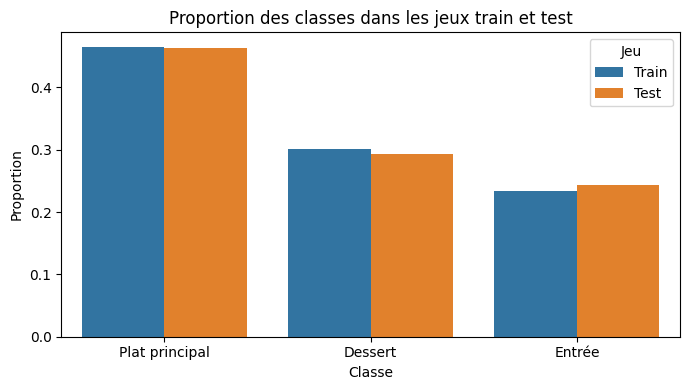

In [8]:
train_props = (
    train["type"]
    .value_counts(normalize=True)
    .rename_axis("Classe")
    .reset_index(name="Proportion")
)
train_props["Jeu"] = "Train"

test_props = (
    test["type"]
    .value_counts(normalize=True)
    .rename_axis("Classe")
    .reset_index(name="Proportion")
)
test_props["Jeu"] = "Test"

df_props = pd.concat([train_props, test_props], ignore_index=True)

order_classes = df_props["Classe"].unique()

plt.figure(figsize=(7,4))
sns.barplot(data=df_props, x="Classe", y="Proportion", hue="Jeu", order=order_classes)

plt.title("Proportion des classes dans les jeux train et test")
plt.xlabel("Classe")
plt.ylabel("Proportion")
plt.tight_layout()
plt.savefig("../figure/proportion_classes_train_test.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
# Colonnes à analyser
cols = ["ingredients", "recette", "text"]

# Création des longueurs
for col in cols:
    train[f"len_{col}"] = train[col].str.split().apply(len)

# Fonction pour créer un tableau de stats pour une colonne
def make_length_table(df, label_col, len_col):
    by_class = df.groupby(label_col)[len_col].agg([
        "count", "mean", "std", "min", "median", "max"
    ])
    
    total = pd.DataFrame(
        df[len_col].agg(["count", "mean", "std", "min", "median", "max"])
    ).T
    total.index = ["Total"]
    
    return pd.concat([by_class, total]).round(2)

# Un tableau par champ
stats_ingredients = make_length_table(train, "type", "len_ingredients")
stats_recette = make_length_table(train, "type", "len_recette")
stats_text = make_length_table(train, "type", "len_text")

In [53]:
print("=== Longueur des ingredients ===")
display(stats_ingredients)

print("=== Longueur de la recette ===")
display(stats_recette)

print("=== Longueur du text ===")
display(stats_text)

=== Longueur des ingredients ===


,count,mean,std,min,median,max
Dessert,3762.0,45.55,21.32,7.0,41.0,223.0
Entrée,2909.0,44.44,18.95,8.0,41.0,149.0
Plat principal,5802.0,49.59,22.05,8.0,46.0,232.0
Total,12473.0,47.17,21.26,7.0,43.0,232.0


=== Longueur de la recette ===


,count,mean,std,min,median,max
Dessert,3762.0,125.56,77.35,9.0,108.0,1334.0
Entrée,2909.0,112.62,58.33,14.0,101.0,638.0
Plat principal,5802.0,127.73,65.01,13.0,114.0,1213.0
Total,12473.0,123.55,67.83,9.0,109.0,1334.0


=== Longueur du text ===


,count,mean,std,min,median,max
Dessert,3762.0,176.00,90.84,33.0,155.0,1450.0
Entrée,2909.0,162.20,69.33,25.0,149.0,763.0
Plat principal,5802.0,182.59,78.81,44.0,166.5,1440.0
Total,12473.0,175.85,81.01,25.0,159.0,1450.0


- count = 12473 : 12 473 recettes
- mean = 175.85 : en moyenne, une ligne fait ~176 mots.
- std = 81.01 : l’écart-type (dispersion).
- min = 25 : la plus courte ligne a 25 mots.

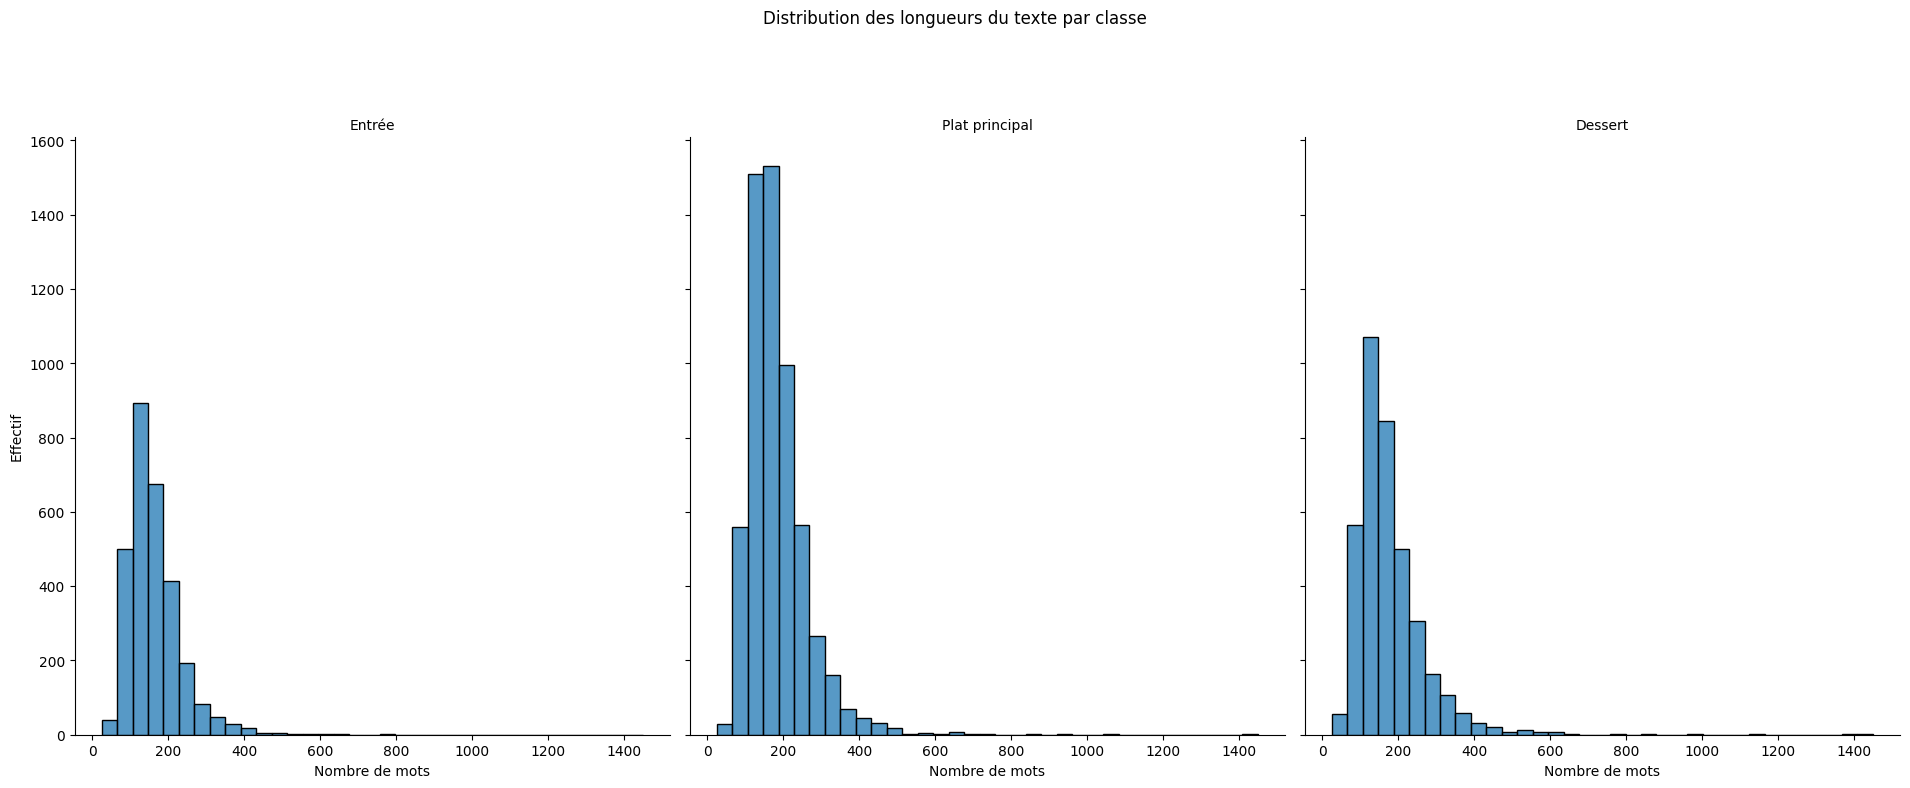

In [54]:
g = sns.displot(
    data=train,
    x="len_text",
    col="type",
    col_order=["Entrée", "Plat principal", "Dessert"],
    col_wrap=3,
    bins=35,
    height=8,
    aspect=0.8
)

g.set_axis_labels("Nombre de mots", "Effectif")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Distribution des longueurs du texte par classe")

plt.savefig("../figure/longueur_textes_hist_par_classe.png", dpi=300, bbox_inches="tight")
plt.show()

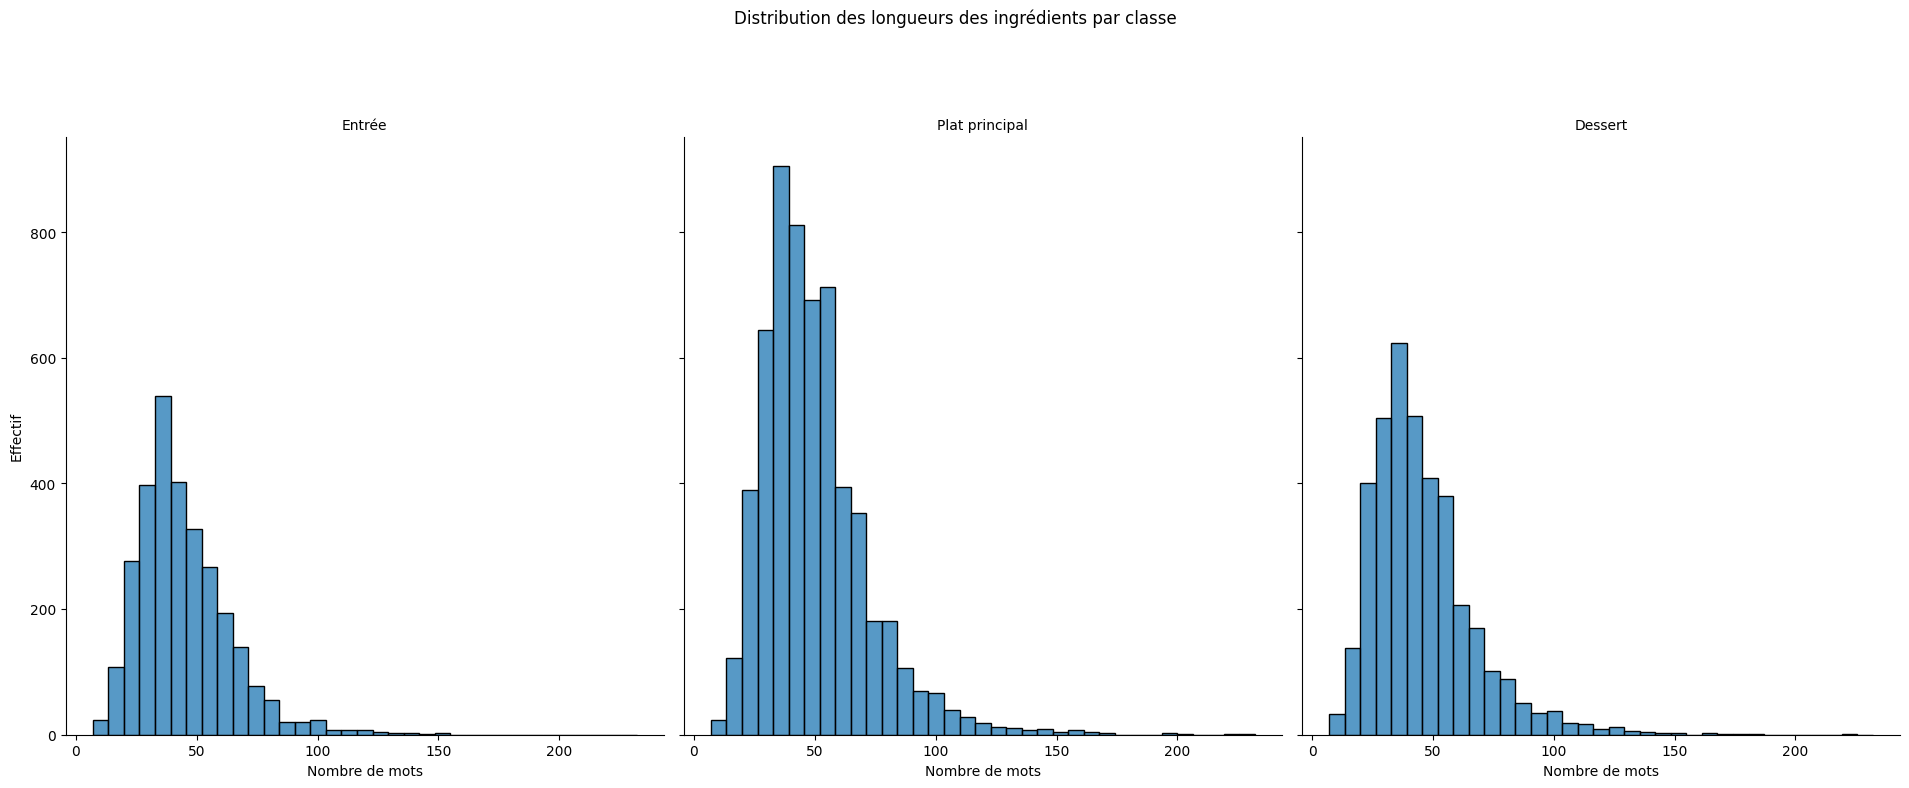

In [55]:
g = sns.displot(
    data=train,
    x="len_ingredients",
    col="type",
    col_order=["Entrée", "Plat principal", "Dessert"],
    col_wrap=3,
    bins=35,
    height=8,
    aspect=0.8
)

g.set_axis_labels("Nombre de mots", "Effectif")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Distribution des longueurs des ingrédients par classe")

plt.savefig("../figure/longueur_ingredients_hist_par_classe.png", dpi=300, bbox_inches="tight")
plt.show()

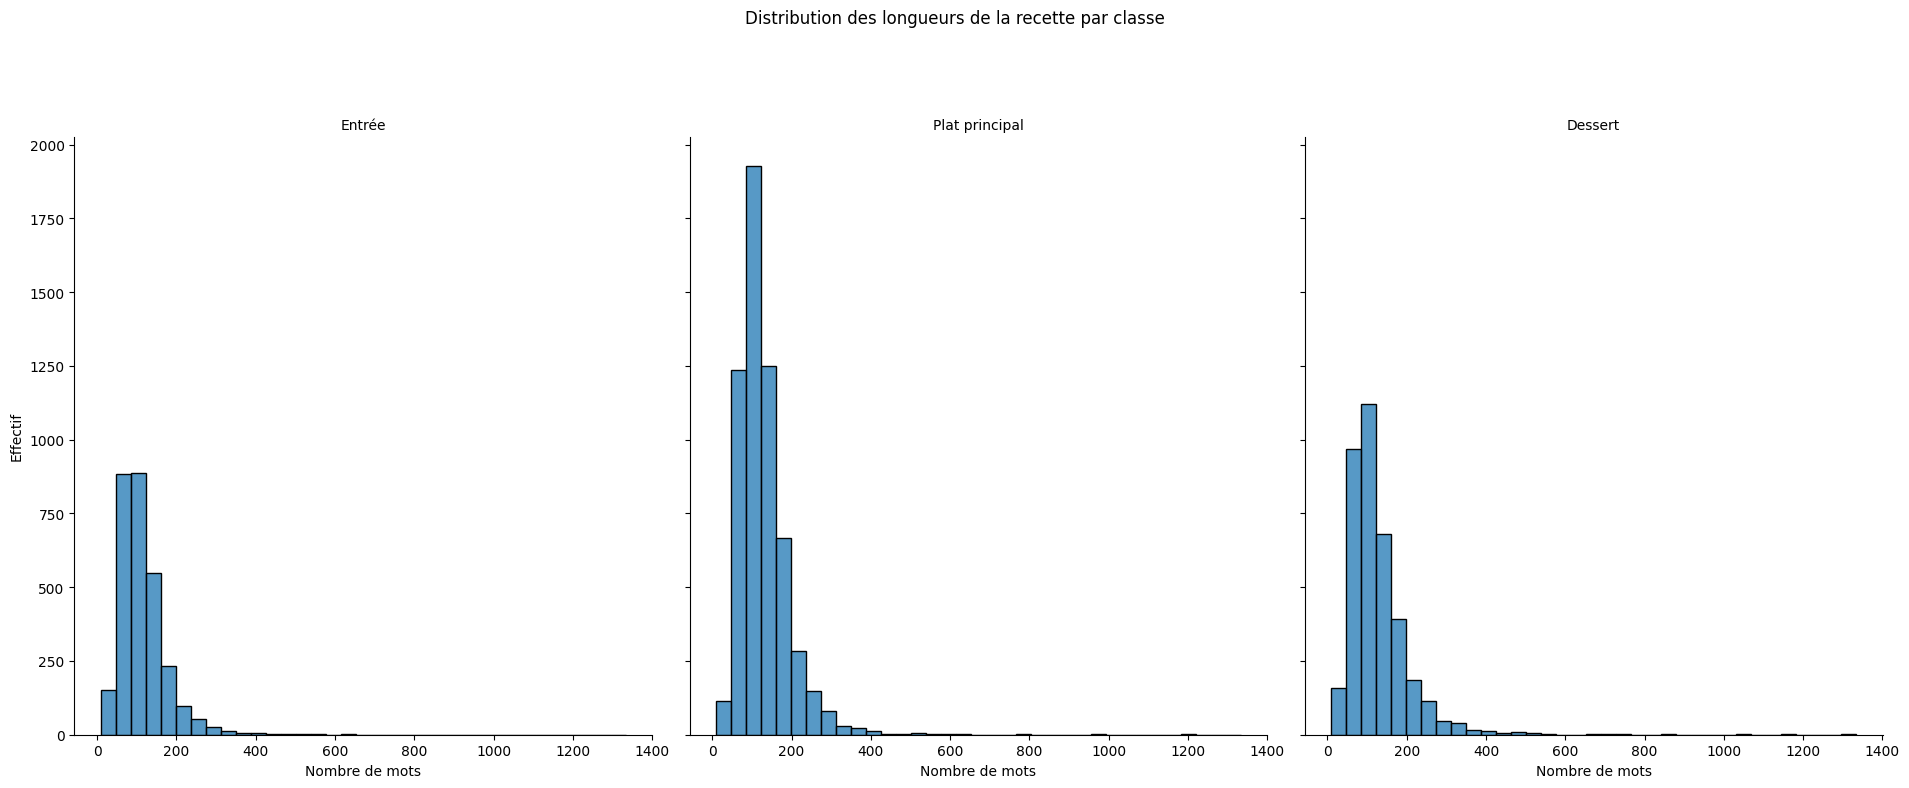

In [56]:
g = sns.displot(
    data=train,
    x="len_recette",
    col="type",
    col_order=["Entrée", "Plat principal", "Dessert"],
    col_wrap=3,
    bins=35,
    height=8,
    aspect=0.8
)

g.set_axis_labels("Nombre de mots", "Effectif")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Distribution des longueurs de la recette par classe")

plt.savefig("../figure/longueur_recettes_hist_par_classe.png", dpi=300, bbox_inches="tight")
plt.show()

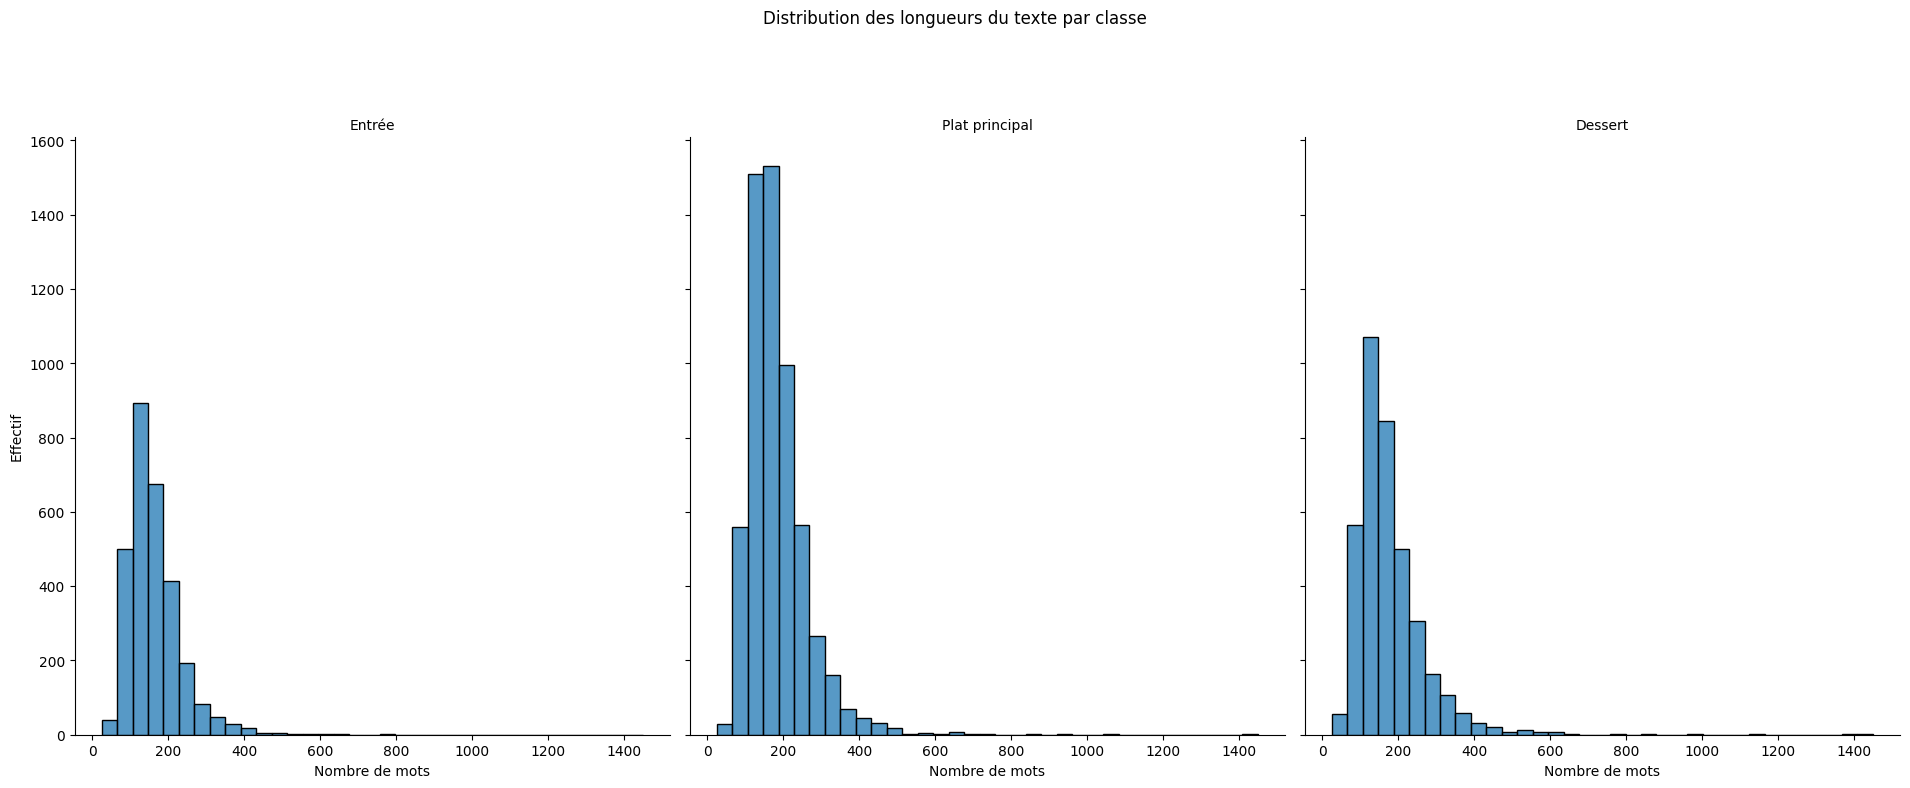

In [57]:
g = sns.displot(
    data=train,
    x="len_text",
    col="type",
    col_order=["Entrée", "Plat principal", "Dessert"],
    col_wrap=3,
    bins=35,
    height=8,
    aspect=0.8
)

g.set_axis_labels("Nombre de mots", "Effectif")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Distribution des longueurs du texte par classe")

plt.savefig("../figure/longueur_textes_hist_par_classe.png", dpi=300, bbox_inches="tight")
plt.show()

### Spécificités lexicales par classe

In [12]:
french_stopwords = set(stopwords.words("french"))

def tokenize(text, strip_accents=False):
    """
    Tokenisation :
    - minuscule
    - suppression des élisions fréquentes : d', l', qu', ...
    - extraction des mots
    - suppression des stopwords français
    - suppression des tokens trop courts
    """
    if not isinstance(text, str):
        return []

    text = text.lower()

    # enlève les élisions fréquentes : d'asperge -> asperge, l'avocat -> avocat
    text = re.sub(r"\b(?:d|l|j|m|n|s|t|c|qu)'", "", text)

    # extrait les mots alphabétiques (avec accents et tirets)
    tokens = re.findall(r"[a-zàâçéèêëîïôûùüÿñæœ]+(?:-[a-zàâçéèêëîïôûùüÿñæœ]+)*", text)

    stopwords_set = french_stopwords

    # filtre stopwords + longueur minimale
    tokens = [
        tok for tok in tokens
        if len(tok) >= 3 and tok not in stopwords_set
    ]

    return tokens

In [13]:
def top_specific_words_by_class(df, text_col="text", label_col="type", top_n=15, min_freq=5):
    results = {}

    # tokens de tout le corpus
    all_tokens = df[text_col].fillna("").apply(tokenize)

    for classe in sorted(df[label_col].unique()):
        mask = df[label_col] == classe

        class_tokens = [tok for doc in all_tokens[mask] for tok in doc]
        other_tokens = [tok for doc in all_tokens[~mask] for tok in doc]

        class_counts = Counter(class_tokens)
        other_counts = Counter(other_tokens)

        total_class = sum(class_counts.values())
        total_other = sum(other_counts.values())

        scores = []
        vocab = set(class_counts.keys())

        for word in vocab:
            if class_counts[word] < min_freq:
                continue

            # fréquences relatives + lissage
            freq_class = (class_counts[word] + 1) / (total_class + 1)
            freq_other = (other_counts[word] + 1) / (total_other + 1)

            # ratio_specificite = P(mot | classe) / P(mot | hors_classe)
            ratio = freq_class / freq_other

            scores.append((word, class_counts[word], other_counts[word], ratio))

        # tri par ratio décroissant puis fréquence dans la classe
        scores = sorted(scores, key=lambda x: (x[3], x[1]), reverse=True)[:top_n]

        results[classe] = pd.DataFrame(
            scores,
            columns=["mot", "freq_classe", "freq_hors_classe", "ratio_specificite"]
        )

    return results

In [14]:
# Execution
specific_words = top_specific_words_by_class(
    train,
    text_col="text",
    label_col="type",
    top_n=50,
    min_freq=5
)

# Affichage
for classe, df_words in specific_words.items():
    print(f"\n=== {classe} ===")
    print(df_words.to_string(index=False))


=== Dessert ===
        mot  freq_classe  freq_hors_classe  ratio_specificite
    biscuit          311                 1         377.388602
    ganache           93                 0         227.400824
     pralin           83                 0         203.209247
   chocolat         4022                49         194.645429
 pâtissière          156                 1         189.903880
   meringue          141                 1         171.760197
   biscuits          760                10         167.361728
 frangipane           63                 0         154.826093
    génoise          186                 2         150.794164
  spéculoos          235                 3         142.730305
      glace         1343                22         141.362955
  speculoos           56                 0         137.891989
    glaçage          280                 4         135.956663
    brownie           54                 0         133.053674
    pépites          271                 4         13

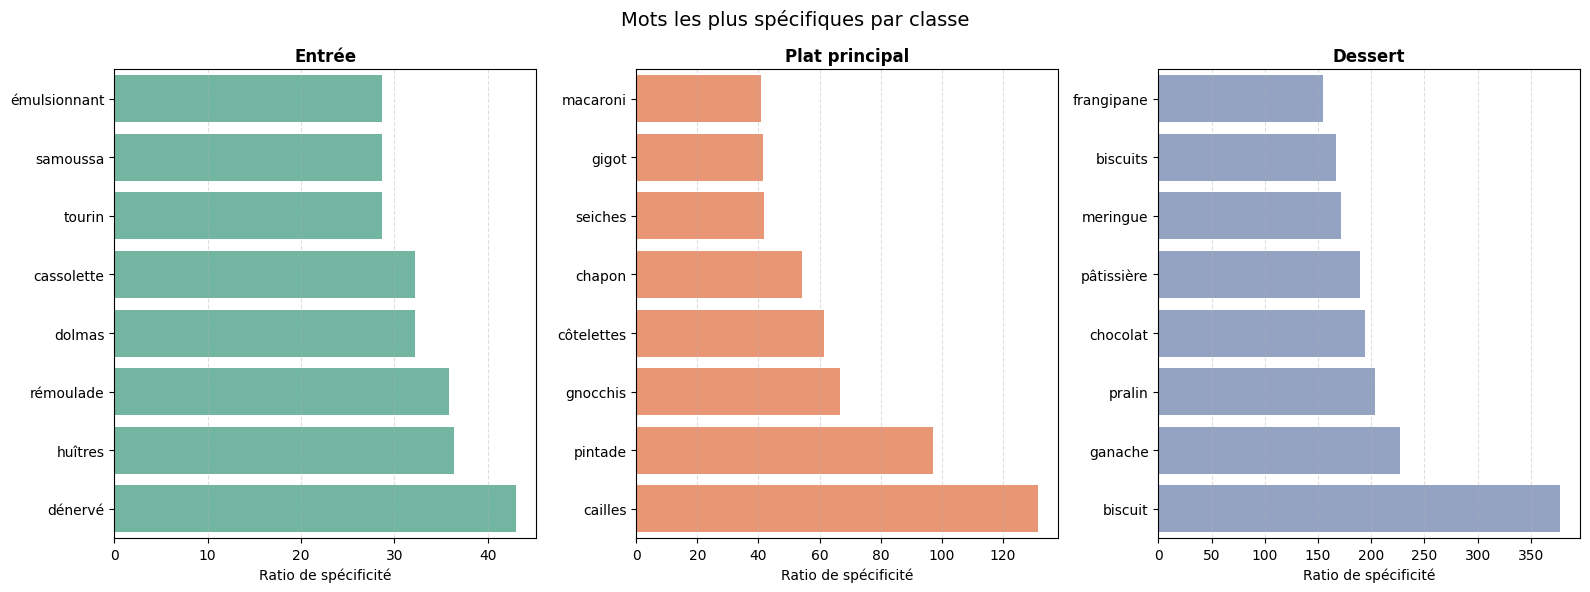

In [15]:
top_n = 8
classes = ["Entrée", "Plat principal", "Dessert"]
palette_classes = {
    "Entrée": "#66c2a5",
    "Plat principal": "#fc8d62",
    "Dessert": "#8da0cb"
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=False)

for ax, classe in zip(axes, classes):
    subset = (
        specific_words[classe]
        .sort_values("ratio_specificite", ascending=True)
        .tail(top_n)
    )

    sns.barplot(
        data=subset,
        x="ratio_specificite",
        y="mot",
        ax=ax,
        color=palette_classes[classe]
    )

    ax.set_title(classe, fontsize=12, fontweight="bold")
    ax.set_xlabel("Ratio de spécificité")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle("Mots les plus spécifiques par classe", fontsize=14)
plt.tight_layout()
plt.savefig("../figure/specificites_lexicales_par_classe.png", dpi=300, bbox_inches="tight")
plt.show()

Pour chaque classe, nous avons extrait les mots les plus spécifiques en comparant leur fréquence relative dans la classe à leur fréquence relative dans le reste du corpus. Cette mesure de surreprésentation permet d’identifier les termes caractéristiques de chaque catégorie, au-delà des mots simplement fréquents dans l’ensemble des recettes.

### Fonction d'évaluation

In [16]:
X_train = train["text"]
y_train = train["type"]

X_test = test["text"]
y_test = test["type"]

In [17]:
random_state = 42
# cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

In [18]:
# micro-F1 : F1 globale en agrégeant toutes les classes (les classes fréquentes pèsent plus)
# macro-F1 : moyenne des F1 calculées séparément pour chaque classe (toutes les classes pèsent pareil)
# accuracy : pourcentage de prédictions correctes

# Fonction d'évaluation pour une méthode
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    final_model = clone(model) # pour etre sur que le modele ne connaissent rien
    final_model.fit(X_train, y_train) # apprentissage
    y_pred = final_model.predict(X_test) # test

    micro = f1_score(y_test, y_pred, average="micro")
    macro = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== {name} ===")
    print("micro-F1 :", micro)
    print("macro-F1 :", macro)
    print("accuracy :", acc)

    print("\n=== Classification report ===")
    print(classification_report(y_test, y_pred, digits=3))

    labels = np.unique(y_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    print("\n=== Matrice de confusion ===")
    print(labels)
    print(cm)

    # pour le tableau de comparaison entre méthode
    return {
        "Méthode": name,
        "micro-F1": micro,
        "macro-F1": macro,
        "accuracy": acc,
        "y_pred": y_pred
    }

In [19]:
# Avec cross validate pour ne pas utiliser le fichier de test.

def evaluate_model_cv(name, model, X, y, cv):
    scores = cross_validate(
        model, X, y, cv=cv,
        scoring={
            "micro_f1": "f1_micro",
            "macro_f1": "f1_macro",
            "acc": "accuracy"
        }
    )

    micro = scores["test_micro_f1"].mean()
    macro = scores["test_macro_f1"].mean()
    acc = scores["test_acc"].mean()

    print(f"\n=== {name} ===")
    print("micro-F1 :", micro)
    print("macro-F1 :", macro)
    print("accuracy :", acc)

    y_pred = cross_val_predict(model, X, y, cv=cv)

    print("\n=== Classification report ===")
    print(classification_report(y, y_pred, digits=3))

    labels = sorted(y.unique())
    cm = confusion_matrix(y, y_pred, labels=labels)

    print("\n=== Matrice de confusion ===")
    print(labels)
    print(cm)

    return {
        "Méthode": name,
        "micro-F1": micro,
        "macro-F1": macro,
        "accuracy": acc
    }

In [20]:
# Pour l'analyse des résulats finales:
results = []

### Les titres seuls sont-ils discriminants ? 
### Les instructions seules suffisent-elles ?
### Certaines recettes semblent-elles ambiguës ?

In [21]:
X_titre = train["titre"].fillna("")
X_recette = train["recette"].fillna("")

On utilise le même pipeline TF-IDF + LinearSVC pour comparer titre seul, recette seule et texte complet de façon équitable. Ainsi, les différences de résultats viennent du champ utilisé, pas d’un changement de méthode.  
TF IDF: vecteur de mots pondérés seulon l'importance.  
LinearSVC: classifieur 

In [22]:
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

In [23]:
results_exploration = []

# On test avec cv sur le fichier train pour ne pas influencer les résulats lors du test final.
results_exploration.append(evaluate_model_cv("Titre seul", model, X_titre, y_train, cv))
results_exploration.append(evaluate_model_cv("Recette seule", model, X_recette, y_train, cv))
results_exploration.append(evaluate_model_cv("Texte complet", model, X_train, y_train, cv))


=== Titre seul ===
micro-F1 : 0.8232172444327308
macro-F1 : 0.8079391205435345
accuracy : 0.8232172444327308

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.919     0.926     0.923      3762
        Entrée      0.696     0.642     0.668      2909
Plat principal      0.820     0.847     0.833      5802

      accuracy                          0.823     12473
     macro avg      0.812     0.805     0.808     12473
  weighted avg      0.821     0.823     0.822     12473


=== Matrice de confusion ===
['Dessert', 'Entrée', 'Plat principal']
[[3483   93  186]
 [ 144 1869  896]
 [ 162  724 4916]]

=== Recette seule ===
micro-F1 : 0.8608197308811689
macro-F1 : 0.8452838843643683
accuracy : 0.8608197308811689

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.968     0.986     0.977      3762
        Entrée      0.740     0.657     0.696      2909
Plat principal      0.844 

In [24]:
results_exploration_df = pd.DataFrame(results_exploration)
results_exploration_df

,Méthode,micro-F1,macro-F1,accuracy
0,Titre seul,0.823217,0.807939,0.823217
1,Recette seule,0.860820,0.845284,0.860820
2,Texte complet,0.870440,0.857163,0.870440


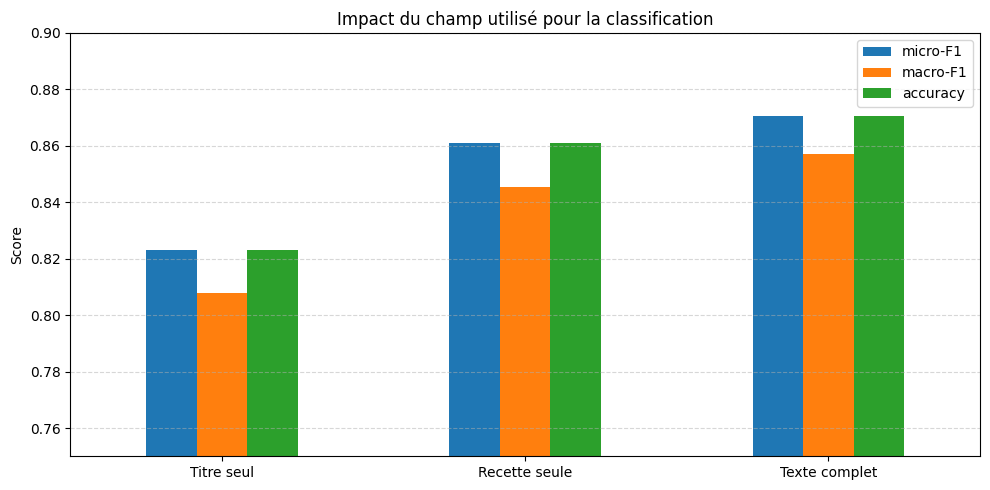

In [25]:
plot_df = results_exploration_df.set_index("Méthode")[["micro-F1", "macro-F1", "accuracy"]]

ax = plot_df.plot(kind="bar", figsize=(10,5))
plt.title("Impact du champ utilisé pour la classification")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0.75, 0.9)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../figure/comparaison_champs.png", dpi=300, bbox_inches="tight")
plt.show()

##### Les titres seuls sont-ils discriminants ? 
Les titres seuls sont déjà assez discriminants, ce qui montre qu’ils contiennent souvent des indices lexicaux forts sur le type de recette. Mais ils ne suffisent pas toujours à bien distinguer les entrées des plats.  

##### Les instructions seules suffisent-elles ?
Les instructions permettent d’obtenir de bonnes performances, supérieures à celles du titre seul. Elles contiennent une information très utile pour la classification.  
Le texte complet reste meilleur, ce qui montre que les autres champs apportent une information complémentaire.

##### Certaines recettes semblent-elles ambiguës ?
Oui, les chiffres montrent que l’ambiguïté concerne surtout Entrée et Plat principal. Avec le texte complet, 865 entrées sont classées comme plats, et 643 plats comme entrées.  
À l’inverse, les desserts sont beaucoup plus faciles à reconnaître (F1 = 0.986, contre 0.717 pour Entrée).

# Baseline

In [26]:
# Baseline Aleatoire
rand_baseline = DummyClassifier(strategy="uniform", random_state=random_state)

results_random = evaluate_model(
    "Baseline aléatoire",
    rand_baseline,
    X_train, y_train,
    X_test, y_test
)

results.append(results_random)


=== Baseline aléatoire ===
micro-F1 : 0.31556195965417866
macro-F1 : 0.30925500105011516
accuracy : 0.31556195965417866

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.265     0.312     0.287       407
        Entrée      0.235     0.315     0.269       337
Plat principal      0.449     0.318     0.372       644

      accuracy                          0.316      1388
     macro avg      0.316     0.315     0.309      1388
  weighted avg      0.343     0.316     0.322      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[127 135 145]
 [124 106 107]
 [228 211 205]]


In [27]:
# Baseline 2 : Classe majoritaire
# Le but est de faire un modele bete qui trouve tjrs en sortie la classe majoritaire (Plat principal) afin d'avoir une baseline.

# faux modèle qui va apprndre la classe la plus fréquente
majoritaire_baseline = DummyClassifier(strategy="most_frequent")

results_majoriatire = evaluate_model(
    "Baseline majoritaire",
    majoritaire_baseline,
    X_train, y_train,
    X_test, y_test
)

results.append(results_majoriatire)


=== Baseline majoritaire ===
micro-F1 : 0.46397694524495675
macro-F1 : 0.21128608923884515
accuracy : 0.46397694524495675

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.000     0.000     0.000       407
        Entrée      0.000     0.000     0.000       337
Plat principal      0.464     1.000     0.634       644

      accuracy                          0.464      1388
     macro avg      0.155     0.333     0.211      1388
  weighted avg      0.215     0.464     0.294      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[  0   0 407]
 [  0   0 337]
 [  0   0 644]]


c:\Users\33784\Documents\Cours\M1_ATAL\S2\TAL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\33784\Documents\Cours\M1_ATAL\S2\TAL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\33784\Documents\Cours\M1_ATAL\S2\TAL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

# Evalutation

## Méthode A: TF-IDF + Naive Bayes

In [28]:
# Méthode A:

# Représentation sac de mots : TF-IDF
# Unités : unigrammes (ngram_range=(1,1))
# Classifieur : Naive Bayes (MultinomialNB)

runA = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 1),   # unigrammes
        min_df=2              # ignore mots trop rares
    )),
    ("clf", MultinomialNB(alpha=1.0))  # alpha = lissage de Laplace (testable)
])

In [29]:
results_A = evaluate_model(
    "Run A unigrammes + NB",
    runA,
    X_train, y_train,
    X_test, y_test
)
results.append(results_A)


=== Run A unigrammes + NB ===
micro-F1 : 0.8054755043227666
macro-F1 : 0.7322642102241345
accuracy : 0.8054755043227666

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.960     0.998     0.978       407
        Entrée      0.884     0.249     0.389       337
Plat principal      0.722     0.975     0.830       644

      accuracy                          0.805      1388
     macro avg      0.855     0.741     0.732      1388
  weighted avg      0.831     0.805     0.766      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[406   0   1]
 [ 12  84 241]
 [  5  11 628]]


## Méthode B: Logistic Regression + TF-IDF + n-grams (1–2)

In [30]:
runB_LogisticRegression = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=random_state
    ))
])

In [31]:
results_B_LogisticRegression = evaluate_model(
    "Run B TF-IDF (1,2) + LogReg",
    runB_LogisticRegression,
    X_train, y_train,
    X_test, y_test
)

results.append(results_B_LogisticRegression)


=== Run B TF-IDF (1,2) + LogReg ===
micro-F1 : 0.8717579250720461
macro-F1 : 0.8593281789236973
accuracy : 0.8717579250720461

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.978     0.993     0.985       407
        Entrée      0.791     0.662     0.721       337
Plat principal      0.841     0.905     0.872       644

      accuracy                          0.872      1388
     macro avg      0.870     0.853     0.859      1388
  weighted avg      0.869     0.872     0.869      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[404   1   2]
 [  6 223 108]
 [  3  58 583]]


## Méthode B: SVM + TF-IDF + n-grams (1–2)

In [32]:
runB_SVM = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LinearSVC())
])

In [33]:
results_B_SVM = evaluate_model(
    "Run B TF-IDF (1,2) + SVM",
    runB_SVM,
    X_train, y_train,
    X_test, y_test
)
results.append(results_B_SVM)


=== Run B TF-IDF (1,2) + SVM ===
micro-F1 : 0.877521613832853
macro-F1 : 0.8680793986836911
accuracy : 0.877521613832853

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.983     0.998     0.990       407
        Entrée      0.780     0.703     0.739       337
Plat principal      0.857     0.893     0.875       644

      accuracy                          0.878      1388
     macro avg      0.873     0.865     0.868      1388
  weighted avg      0.875     0.878     0.876      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[406   1   0]
 [  4 237  96]
 [  3  66 575]]


## Méthode C: Modèle enrichi

Ajout de features linguistiques :  
- longueur
- présence de termes sucrés/salés
- nombre d’ingrédients
- Comparaison avec version sans enrichissement

In [34]:
X_train = train[["text", "ingredients"]]
y_train = train["type"]

X_test = test[["text", "ingredients"]]
y_test = test["type"]

In [35]:
# Dictionnaire de lexiques
# Repris des résultats lors de l'analyse des spécificités lexicales par classe

class_specific_lexicons = {
    classe: set(df_words["mot"].str.lower().tolist())
    for classe, df_words in specific_words.items()
}

print("Lexiques par classe :")
for classe, lex in class_specific_lexicons.items():
    print(classe, "->", len(lex), "mots")
    print(class_specific_lexicons[classe])

Lexiques par classe :
Dessert -> 50 mots
{'blanchiment', 'chocolatée', 'biscuit', 'extrait', 'cookies', 'entremets', 'fraise', 'spéculos', 'brownies', 'meringue', 'nougatine', 'spéculoos', 'meringuée', 'toblerone', 'choco', 'framboises', 'nougat', 'carambars', 'cacao', 'édulcorant', 'blanchisse', 'speculoos', 'pralines', 'brownie', 'meringues', 'reims', 'génoise', 'glace', 'quetsches', 'nutella', 'glaçage', 'fraises', 'biscuits', 'tagada', 'pâtissier', 'ganache', 'vanillé', 'pudding', 'praliné', 'gâteau', 'frangipane', 'pralin', 'pâtissière', 'macarons', 'sablés', 'chocolat', 'financiers', 'tiramisu', 'chocolats', 'pépites'}
Entrée -> 50 mots
{'ballotins', 'croustades', 'bandelette', 'saumonette', 'potage', 'avocat', 'rillette', 'mouillettes', 'lobes', 'tahiné', 'émulsionnant', 'velouté', 'emulsionner', 'rissois', 'avocats', 'cassolettes', 'emulsionnez', 'croutons', 'baluchon', 'concombres', 'amuse', 'fortes', 'dénervé', 'blinis', 'samoussa', 'halloumi', 'cassolette', 'clovisses', 'sam

### Features sucré/salé

In [36]:
# Transformer custom:
# prendre un texte en entrée
# tokeniser ce texte avec tokenize
# compter combien de mots du texte appartiennent à chaque lexique de classe

class ClassSpecificWordFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, class_lexicons):
        self.class_lexicons = class_lexicons
        self.class_names = list(class_lexicons.keys())

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []

        for text in X:
            tokens = tokenize(text)
            token_counts = Counter(tokens)

            row = []
            for classe in self.class_names:
                lexicon = self.class_lexicons[classe]

                # nombre total d'occurrences des mots spécifiques de la classe
                count = sum(freq for tok, freq in token_counts.items() if tok in lexicon)

                # présence binaire
                has_any = int(count > 0)

                row.extend([count, has_any])

            features.append(row)

        return np.array(features, dtype=float)
        # par ex [3, 1, 0, 0, 0, 0]
        # qui correspond a [count_dessert, has_dessert, count_entree, has_entree, count_plat, has_plat]
        # ce vecteur sera concatené avec les autres features puis transformé    



### Features de longueur
L’idée est que certaines classes peuvent avoir des textes plus courts ou plus longs avec plus ou moins de contenu

In [37]:
class TextLengthFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []

        for text in X:
            if not isinstance(text, str):
                text = ""

            n_words = len(text.split())
            n_chars = len(text)

            features.append([n_words, n_chars])

        return np.array(features, dtype=float)
        # [7, 44] pour 
        # n_words = 7
        # n_chars = 44

### Features nb ingrédients
- ColumnSelector sert à extraire une colonne précise du df, ici text ou ingredients, pour l’envoyer au bon bloc du pipeline  
- IngredientCountFeatures calcul le nombre d’ingrédients d'une recette, à partir du contenu de la colonne ingredients.

In [38]:
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, col):
        self.col = col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.col].fillna("")


class IngredientCountFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []

        for txt in X:
            if not isinstance(txt, str) or not txt.strip():
                features.append([0])
                continue

            lines = [line.strip() for line in txt.split("\n") if line.strip()]
            if len(lines) > 1:
                count = len(lines)
            else:
                parts = re.split(r"[,;•\-]+", txt)
                parts = [p.strip() for p in parts if p.strip()]
                count = len(parts)

            features.append([count])

        return np.array(features, dtype=float)

In [39]:
runC_SVM_sans_enrichissement = Pipeline([
    ("tfidf_pipeline", Pipeline([
        ("select_text", ColumnSelector("text")),
        ("tfidf", TfidfVectorizer(
            tokenizer=tokenize,
            preprocessor=None,
            token_pattern=None,
            lowercase=False,
            ngram_range=(1, 2),
            min_df=2
        ))
    ])),
    ("clf", LinearSVC())
])

results_C_features = evaluate_model(
    "Run C sans enrich.",
    runC_SVM_sans_enrichissement,
    X_train, y_train,
    X_test, y_test
)

results.append(results_C_features)


=== Run C sans enrich. ===
micro-F1 : 0.872478386167147
macro-F1 : 0.8625809942900924
accuracy : 0.872478386167147

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.985     0.998     0.991       407
        Entrée      0.766     0.691     0.727       337
Plat principal      0.851     0.888     0.869       644

      accuracy                          0.872      1388
     macro avg      0.868     0.859     0.863      1388
  weighted avg      0.870     0.872     0.871      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[406   1   0]
 [  4 233 100]
 [  2  70 572]]


In [40]:
# FeatureUnion pour concatener horizontalement toutes les features.
# [TFIDF_1, TFIDF_2, ..., TFIDF_n, count_dessert, has_dessert, count_entree, has_entree, count_plat, has_plat, n_words, n_chars]

# StandardScaler() sert à standardiser les petites features numériques ajoutées sinon certaines colonnes vont peser plus

runC_SVM_full = Pipeline([
    ("features", FeatureUnion([
        ("tfidf", Pipeline([
            ("select_text", ColumnSelector("text")),
            ("tfidf", TfidfVectorizer(
                tokenizer=tokenize,
                preprocessor=None,
                token_pattern=None,
                lowercase=False,
                ngram_range=(1, 2),
                min_df=2
            ))
        ])),
        ("class_words", Pipeline([
            ("select_text", ColumnSelector("text")),
            ("extract", ClassSpecificWordFeatures(class_specific_lexicons)),
            ("scale", StandardScaler())
        ])),
        ("length", Pipeline([
            ("select_text", ColumnSelector("text")),
            ("extract", TextLengthFeatures()),
            ("scale", StandardScaler())
        ])),
        ("ingredient_count", Pipeline([
            ("select_ing", ColumnSelector("ingredients")),
            ("extract", IngredientCountFeatures()),
            ("scale", StandardScaler())
        ]))
    ])),
    ("clf", LinearSVC())
])



results_C_features = evaluate_model(
    "Run C + features",
    runC_SVM_full,
    X_train, y_train,
    X_test, y_test
)

results.append(results_C_features)

c:\Users\33784\Documents\Cours\M1_ATAL\S2\TAL\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



=== Run C + features ===
micro-F1 : 0.8623919308357348
macro-F1 : 0.8523296433253927
accuracy : 0.8623919308357348

=== Classification report ===
                precision    recall  f1-score   support

       Dessert      0.985     0.995     0.990       407
        Entrée      0.739     0.680     0.708       337
Plat principal      0.844     0.874     0.859       644

      accuracy                          0.862      1388
     macro avg      0.856     0.850     0.852      1388
  weighted avg      0.860     0.862     0.861      1388


=== Matrice de confusion ===
['Dessert' 'Entrée' 'Plat principal']
[[405   2   0]
 [  4 229 104]
 [  2  79 563]]


Dans la méthode C, des variables manuelles ont été ajoutées à la représentation TF-IDF. Elles reposent d’une part sur des lexiques de mots spécifiques à chaque classe, extraits à partir du corpus d’apprentissage, et d’autre part sur des informations de longueur du texte. Pour chaque recette, on calcule le nombre d’occurrences de mots appartenant aux lexiques Dessert, Entrée et Plat principal, ainsi qu’un indicateur binaire de présence pour chacune de ces classes. On ajoute également deux variables de longueur : le nombre de mots et le nombre de caractères du texte. Ces variables numériques sont standardisées puis concaténées aux vecteurs TF-IDF avant l’apprentissage d’un classifieur LinearSVC.

# Analyse

In [41]:
results_df = pd.DataFrame(results).drop(columns=["y_pred"])
results_df

,Méthode,micro-F1,macro-F1,accuracy
0,Baseline aléatoire,0.315562,0.309255,0.315562
1,Baseline majoritaire,0.463977,0.211286,0.463977
2,Run A unigrammes + NB,0.805476,0.732264,0.805476
3,"Run B TF-IDF (1,2) + LogReg",0.871758,0.859328,0.871758
4,"Run B TF-IDF (1,2) + SVM",0.877522,0.868079,0.877522
5,Run C sans enrich.,0.872478,0.862581,0.872478
6,Run C + features,0.862392,0.852330,0.862392


La Run B avec SVM et la Run C sans enrichissement reposent globalement sur la même approche. La seule différence notable est que la Run C applique une tokenisation, afin de conserver un protocole cohérent avec la Run C avec features. Cela explique que les résultats de ces deux méthodes soient très proches. Pour améliorer la lisibilité des figures, nous avons donc choisi de ne pas afficher la Run C sans enrichissement, car elle est très proche de la Run B SVM.

In [42]:
results_df = results_df[results_df["Méthode"] != "Run C sans enrich."]
results_df

,Méthode,micro-F1,macro-F1,accuracy
0,Baseline aléatoire,0.315562,0.309255,0.315562
1,Baseline majoritaire,0.463977,0.211286,0.463977
2,Run A unigrammes + NB,0.805476,0.732264,0.805476
3,"Run B TF-IDF (1,2) + LogReg",0.871758,0.859328,0.871758
4,"Run B TF-IDF (1,2) + SVM",0.877522,0.868079,0.877522
6,Run C + features,0.862392,0.852330,0.862392


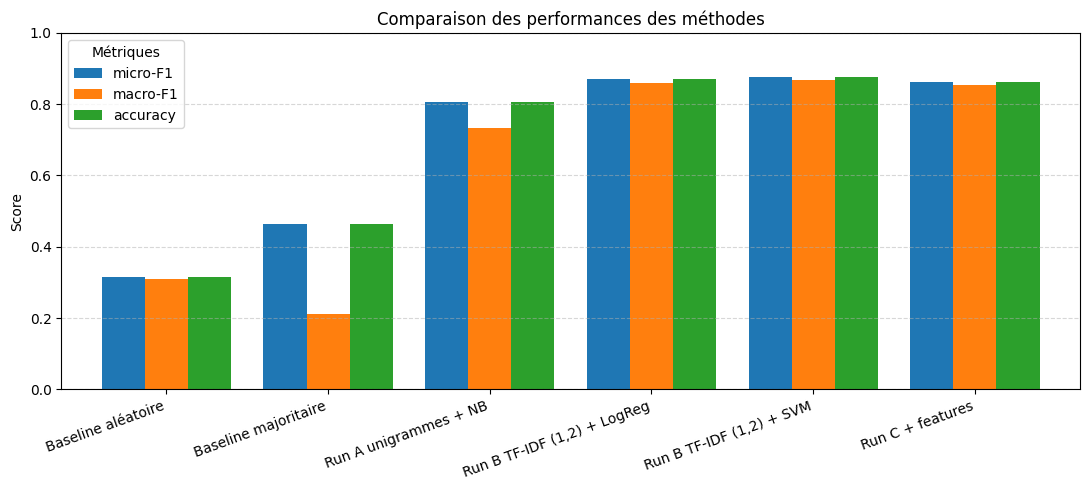

In [43]:
plot_df = results_df.set_index("Méthode")[["micro-F1", "macro-F1", "accuracy"]]

ax = plot_df.plot(kind="bar", figsize=(11,5), width=0.8)
plt.title("Comparaison des performances des méthodes")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Métriques")
plt.tight_layout()
plt.savefig("../figure/comparaison_methodes.png", dpi=300, bbox_inches="tight")
plt.show()

La Run A étant nettement moins performante, nous avons choisi de ne pas l’afficher dans les figures, de la même manière que les baselines, afin de faciliter la comparaison entre les méthodes les plus pertinentes.

In [44]:
results_df = results_df[
    ~results_df["Méthode"].isin([
        "Baseline aléatoire",
        "Baseline majoritaire",
        "Run A unigrammes + NB"
    ])
]

results_df

,Méthode,micro-F1,macro-F1,accuracy
3,"Run B TF-IDF (1,2) + LogReg",0.871758,0.859328,0.871758
4,"Run B TF-IDF (1,2) + SVM",0.877522,0.868079,0.877522
6,Run C + features,0.862392,0.852330,0.862392


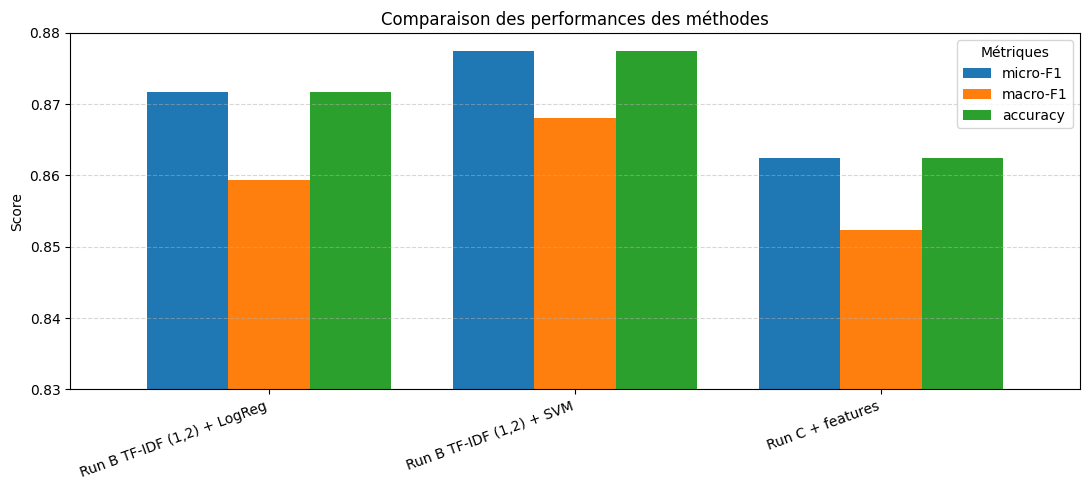

In [45]:
plot_df = results_df.set_index("Méthode")[["micro-F1", "macro-F1", "accuracy"]]

ax = plot_df.plot(kind="bar", figsize=(11,5), width=0.8)
plt.title("Comparaison des performances des méthodes")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0.83, 0.88)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Métriques")
plt.tight_layout()
plt.savefig("../figure/comparaison_methodes.png", dpi=300, bbox_inches="tight")
plt.show()

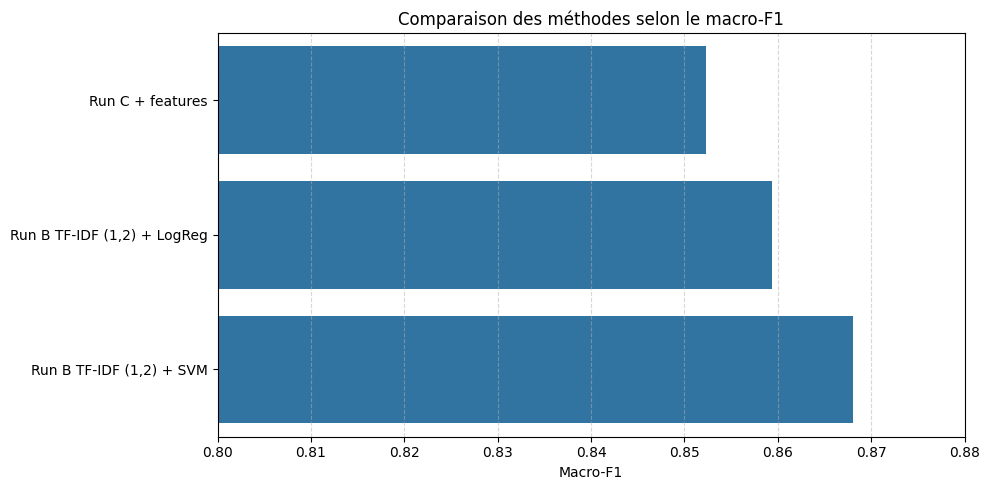

In [46]:
plot_df = results_df[~results_df["Méthode"].str.contains("Baseline", case=False, na=False)].copy()
plot_df = plot_df.sort_values("macro-F1", ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, y="Méthode", x="macro-F1")

plt.title("Comparaison des méthodes selon le macro-F1")
plt.xlabel("Macro-F1")
plt.ylabel("")
plt.xlim(0.8, 0.88)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../figure/comparaison_macro_f1_sans_baselines.png", dpi=300, bbox_inches="tight")
plt.show()

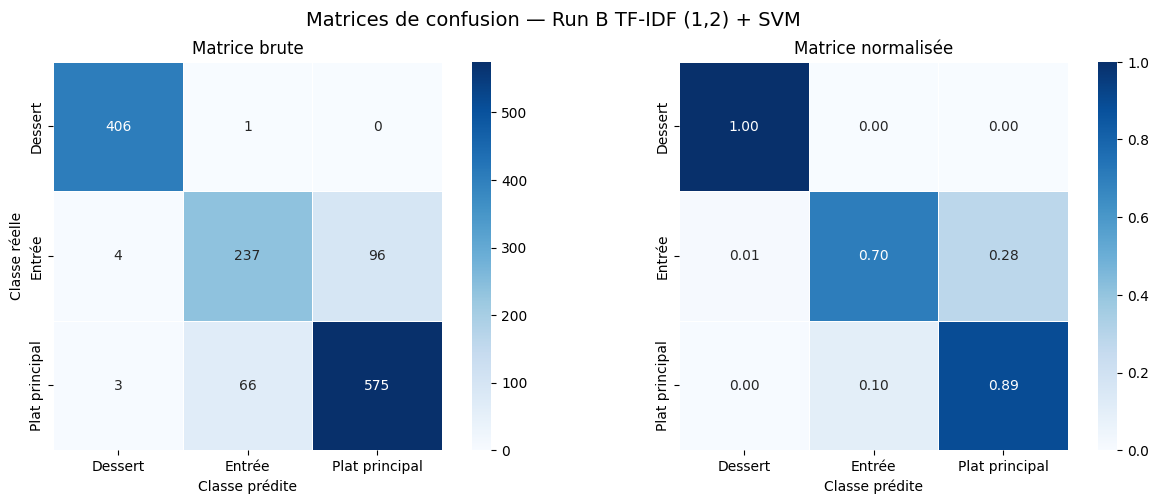

In [47]:
labels = ["Dessert", "Entrée", "Plat principal"]
y_pred_b_svm = results_B_SVM["y_pred"]

cm = confusion_matrix(y_test, y_pred_b_svm, labels=labels)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matrice brute
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
    square=True,
    linecolor="white",
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Matrice brute")
axes[0].set_xlabel("Classe prédite")
axes[0].set_ylabel("Classe réelle")

# Matrice normalisée
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    vmin=0,
    vmax=1,
    cbar=True,
    square=True,
    linecolor="white",
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title("Matrice normalisée")
axes[1].set_xlabel("Classe prédite")
axes[1].set_ylabel("")

fig.suptitle("Matrices de confusion — Run B TF-IDF (1,2) + SVM", fontsize=14)
plt.tight_layout()
plt.savefig("../figure/matrices_confusion_runB_svm.png", dpi=300, bbox_inches="tight")
plt.show()

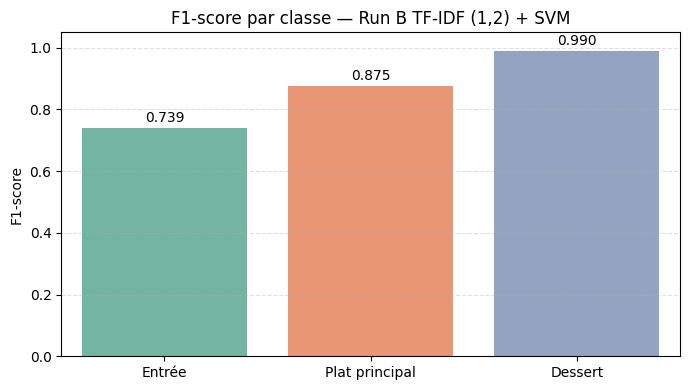

In [48]:
report = classification_report(
    y_test,
    y_pred_b_svm,
    output_dict=True
)

order_classes = ["Entrée", "Plat principal", "Dessert"]

f1_df = pd.DataFrame({
    "Classe": ["Dessert", "Entrée", "Plat principal"],
    "F1-score": [
        report["Dessert"]["f1-score"],
        report["Entrée"]["f1-score"],
        report["Plat principal"]["f1-score"]
    ]
})

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=f1_df,
    x="Classe",
    y="F1-score",
    hue="Classe",
    order=order_classes,
    palette=palette_classes,
    legend=False
)

plt.title("F1-score par classe — Run B TF-IDF (1,2) + SVM")
plt.ylim(0, 1.05)
plt.xlabel("")
plt.ylabel("F1-score")
plt.grid(axis="y", linestyle="--", alpha=0.4)

ordered_values = f1_df.set_index("Classe").loc[order_classes]["F1-score"]
for i, v in enumerate(ordered_values):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("../figure/f1_par_classe_runB_svm.png", dpi=300, bbox_inches="tight")
plt.show()

Le F1-score par classe confirme que la classe Dessert est de loin la mieux reconnue par le modèle. À l’inverse, la classe Entrée obtient le score le plus faible, ce qui reflète une plus grande confusion avec la classe Plat principal. Cette observation est cohérente avec la matrice de confusion.